In [7]:
# Data Handling

import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Processing (NLP)
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Word Cloud
from wordcloud import WordCloud

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Save & Load Model
import joblib

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Load Datasets

In [8]:
data = pd.read_csv("spam.csv", encoding="latin-1")

# Display first 5 records
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Check Dataset Shape

In [9]:
print("Dataset Shape:", data.shape)

Dataset Shape: (5572, 5)


Display Column Names

In [10]:
print("Columns:")
print(data.columns)

Columns:
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


Dataset Information

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


Check Data Types

In [12]:
data.dtypes

,0
v1,object
v2,object
Unnamed: 2,object
Unnamed: 3,object
Unnamed: 4,object


Display Random Samples

In [13]:
data.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3236,ham,Ron say fri leh. N he said ding tai feng cant ...,NaN,NaN,NaN
5537,spam,Want explicit SEX in 30 secs? Ring 02073162414...,NaN,NaN,NaN
2925,ham,Im done. Just studyn in library,NaN,NaN,NaN
933,ham,What time you think you'll have it? Need to kn...,NaN,NaN,NaN
4321,ham,Sorry . I will be able to get to you. See you ...,NaN,NaN,NaN


Check Missing Values

In [14]:
data.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


Dataset Summary

In [15]:
data.describe(include="all")

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


**Data Cleaning**

STEP-1: Remove Unnecessary Columns

In [16]:
data = data[['v1', 'v2']]

STEP-2: Rename Columns

In [17]:
data.columns = ['label', 'text']

STEP-3: Remove Missing Values

In [18]:
data.dropna(inplace=True)

STEP-4:Remove Duplicate Messages

In [19]:
data.drop_duplicates(inplace=True)

print("Dataset Shape After Cleaning:", data.shape)

Dataset Shape After Cleaning: (5169, 2)


STEP-5:Reset Index

In [20]:
data.reset_index(drop=True, inplace=True)

STEP-6: Verify Cleaned Dataset

In [21]:
data.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


**Exploratory Data Analysis (EDA)**

STEP-1: Class Distribution

/tmp/ipykernel_1437/3833570720.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data["label"], palette="Set2")


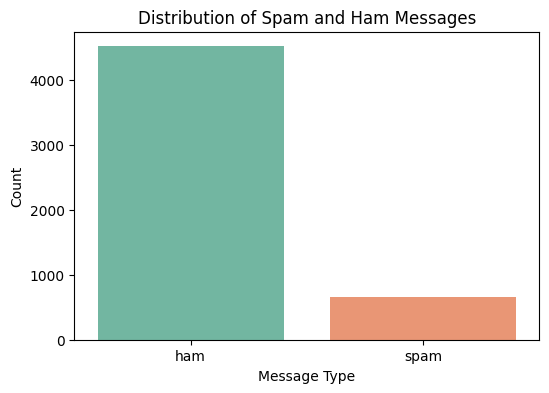

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(x=data["label"], palette="Set2")

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

STEP-2: Percentage Distribution

In [23]:
data["label"].value_counts(normalize=True).mul(100).round(2)

,proportion
label,
ham,87.37
spam,12.63


STEP-3: Pie Chart

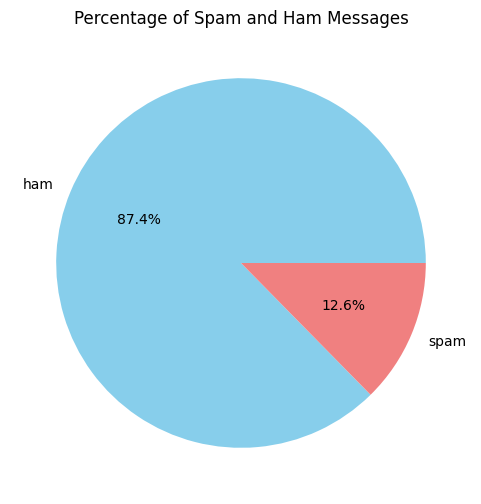

In [24]:
plt.figure(figsize=(6,6))

data["label"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["skyblue","lightcoral"]
)

plt.ylabel("")
plt.title("Percentage of Spam and Ham Messages")

plt.show()

STEP-4: Create New Features

In [25]:
data["message_length"] = data["text"].str.len()

data["word_count"] = data["text"].str.split().apply(len)

STEP-5:Histogram

In [26]:
data["email_length"]=data["text"].apply(len)

In [27]:
data["email_length"].describe()

,email_length
count,5169.000000
mean,78.977945
std,58.236293
min,2.000000
25%,36.000000
50%,60.000000
75%,117.000000
max,910.000000


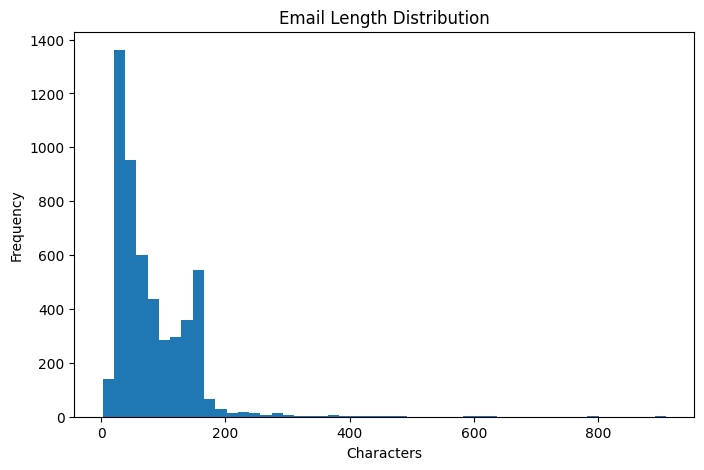

In [28]:
plt.figure(figsize=(8,5))

plt.hist(data["email_length"],bins=50)

plt.title("Email Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

STEP-6: Message Length Analysis

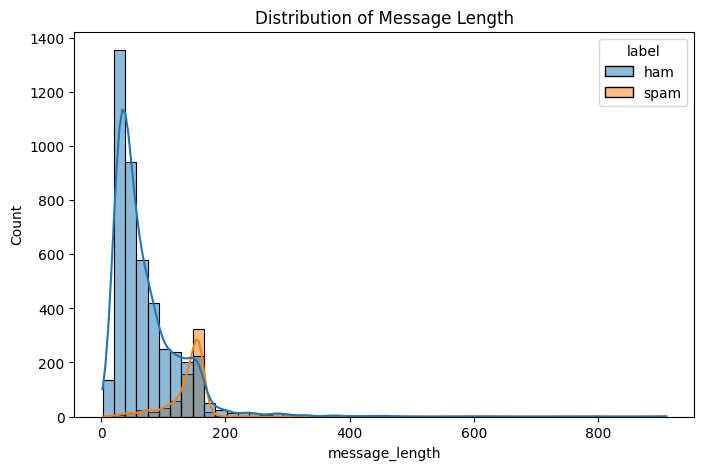

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x="message_length",
    hue="label",
    bins=50,
    kde=True
)

plt.title("Distribution of Message Length")

plt.show()

STEP-7: Word Count Analysis

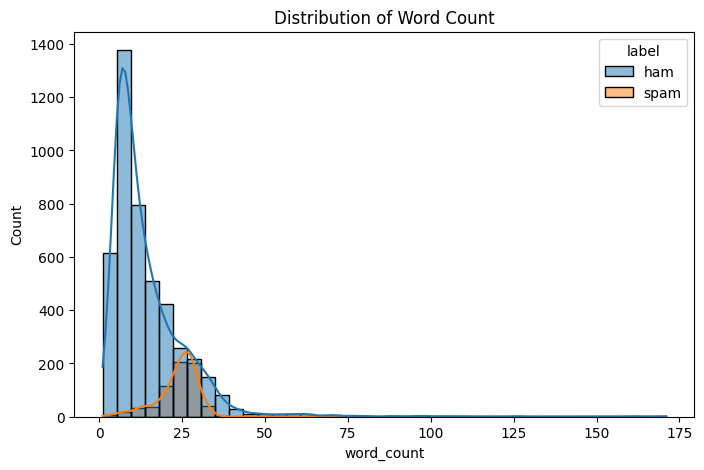

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=data,
    x="word_count",
    hue="label",
    bins=40,
    kde=True
)

plt.title("Distribution of Word Count")

plt.show()

STEP-8:Compare Spam vs Ham **Length**



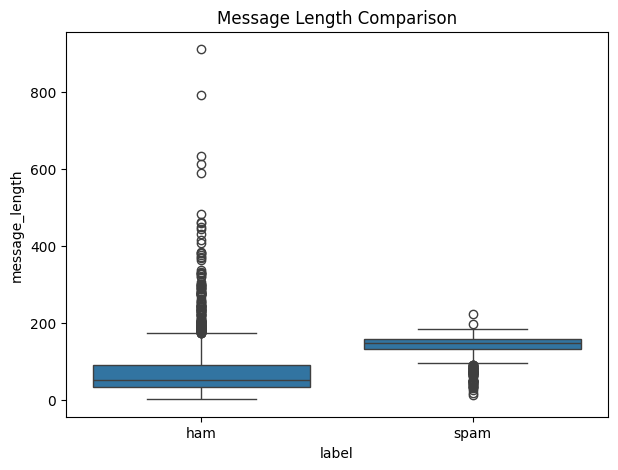

In [31]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="label",
    y="message_length",
    data=data
)

plt.title("Message Length Comparison")

plt.show()

STEP-9:Word Cloud for Spam

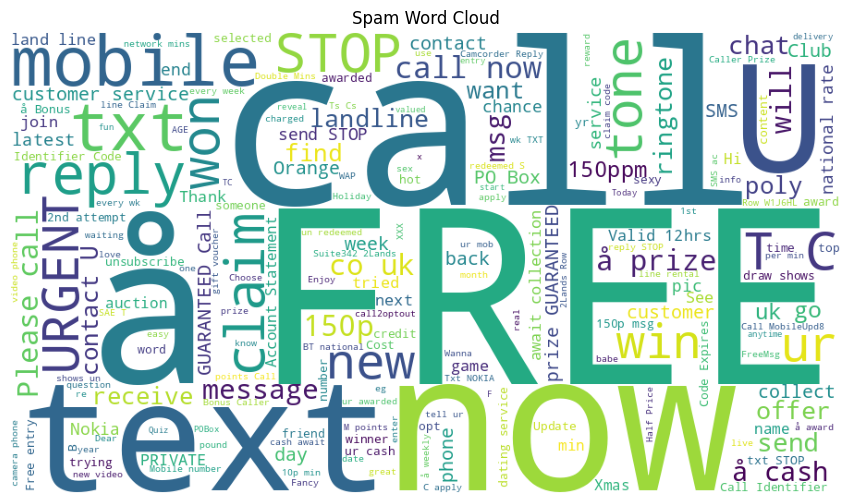

In [32]:
spam_text = " ".join(
    data[data["label"]=="spam"]["text"]
)

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Spam Word Cloud")

plt.show()

STEP-10: Word Cloud for Ham

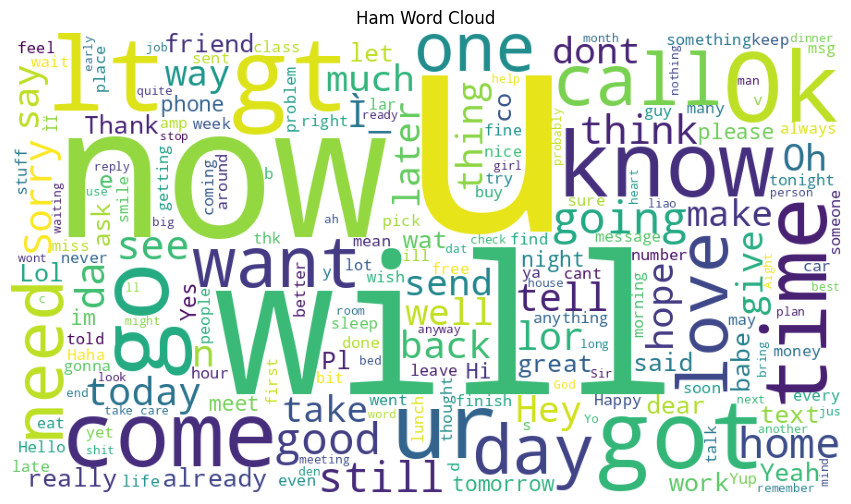

In [33]:
ham_text = " ".join(
    data[data["label"]=="ham"]["text"]
)

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Ham Word Cloud")

plt.show()

STEP-11: Correlation Heatmap

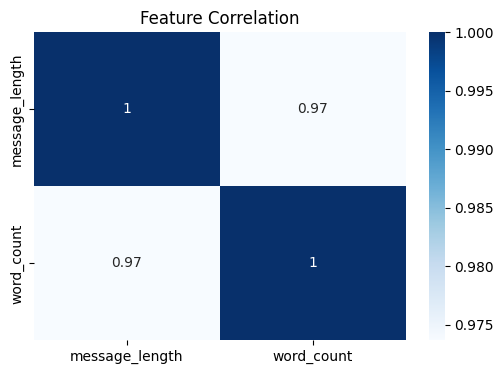

In [34]:
plt.figure(figsize=(6,4))

sns.heatmap(
    data[["message_length","word_count"]].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Feature Correlation")

plt.show()

STEP-12:Most Frequent Words

In [35]:
from collections import Counter

all_words=" ".join(data["text"]).split()

Counter(all_words).most_common(20)

[('to', 1972),
 ('you', 1562),
 ('I', 1375),
 ('a', 1198),
 ('the', 1114),
 ('and', 814),
 ('in', 731),
 ('i', 720),
 ('is', 691),
 ('u', 614),
 ('for', 604),
 ('my', 579),
 ('me', 532),
 ('of', 531),
 ('your', 517),
 ('have', 447),
 ('on', 446),
 ('2', 423),
 ('that', 407),
 ('it', 376)]

STEP-13: Top 20 Words

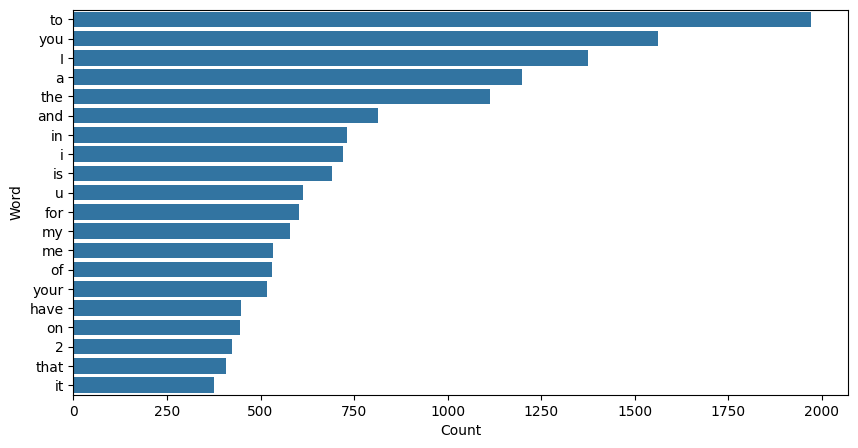

In [36]:
words=Counter(all_words).most_common(20)

word=pd.DataFrame(words,columns=["Word","Count"])

plt.figure(figsize=(10,5))

sns.barplot(data=word,x="Count",y="Word")

plt.show()

**Text Preprocessing**

Step 1: Initialize NLP Objects

In [37]:
# Initialize NLP Objects

stop_words = set(stopwords.words("english"))

stemmer = PorterStemmer()

lemmatizer = WordNetLemmatizer()

Step 2: Create Preprocessing Function

In [38]:
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Stopword Removal
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Stemming
    tokens = [
        stemmer.stem(word)
        for word in tokens
    ]

    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(tokens)

Step 3: Download NLTK Resources

In [39]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [40]:
data["processed_text"] = data["text"].apply(preprocess_text)

Step 4: Compare Original and Processed Text

In [41]:
comparison = data[["text", "processed_text"]]

comparison.head(10)

,text,processed_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darl week word back id like fun st...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aid patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request mell mell oru minnaminungint nurun...
8,WINNER!! As a valued network customer you have...,winner valu network custom select receivea å£ ...
9,Had your mobile 11 months or more? U R entitle...,mobil month u r entitl updat latest colour mob...


Step 5: Remove Empty Messages

In [42]:
data = data[data["processed_text"].str.strip() != ""]

data.reset_index(drop=True, inplace=True)

Step 6: Final Verification

In [43]:
data[["label", "processed_text"]].head()

,label,processed_text
0,ham,go jurong point crazi avail bugi n great world...
1,ham,ok lar joke wif u oni
2,spam,free entri wkli comp win fa cup final tkt st m...
3,ham,u dun say earli hor u c alreadi say
4,ham,nah dont think goe usf live around though


**TF-IDF Feature Extraction**

Step 1: Create TF-IDF Vectorizer

In [44]:
tfidf = TfidfVectorizer(
    max_features=5000
)

Step 2: Transform Text into TF-IDF Features

In [45]:
X = tfidf.fit_transform(data["processed_text"])

y = data["label"]

Step 3: Check Feature Matrix Shape

In [46]:
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (5163, 5000)
Target Shape: (5163,)


Step 4: Display Some TF-IDF Features

In [47]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:20])

['aah' 'aaooooright' 'aathilov' 'aathiwher' 'ab' 'abbey' 'abdomen' 'abeg'
 'abel' 'aberdeen' 'abi' 'abil' 'abiola' 'abj' 'abl' 'abnorm' 'abt' 'abta'
 'aburo' 'abus']


Step 5: Display TF-IDF Matrix

In [48]:
tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,aah,aaooooright,aathilov,aathiwher,ab,abbey,abdomen,abeg,abel,aberdeen,...,zyada,åè,åð,åòharri,åòit,åômorrow,åôrent,ìll,ìï,ûò
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Step 6: Verify Number of Features

In [49]:
print("Total TF-IDF Features:", len(tfidf.get_feature_names_out()))

Total TF-IDF Features: 5000


**Train-Test Split**

Step 1: Split the Dataset

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Step 2: Display Dataset Sizes

In [51]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (4130, 5000)
Testing Features  : (1033, 5000)
Training Labels   : (4130,)
Testing Labels    : (1033,)


Step 3: Verify Class Distribution

In [52]:
print("Training Set Distribution")
print(y_train.value_counts())

print("\nTesting Set Distribution")
print(y_test.value_counts())

Training Set Distribution
label
ham     3608
spam     522
Name: count, dtype: int64

Testing Set Distribution
label
ham     902
spam    131
Name: count, dtype: int64


Step 4: Training vs Testing Percentage

In [53]:
print(f"Training Data : {len(y_train)/len(data)*100:.1f}%")

print(f"Testing Data  : {len(y_test)/len(data)*100:.1f}%")

Training Data : 80.0%
Testing Data  : 20.0%


**Model Building**

Step 1: Initialize Models

In [54]:
nb_model = MultinomialNB()

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

svm_model = LinearSVC(
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

Step 2: Train Multinomial Naive Bayes

In [55]:
nb_model.fit(X_train, y_train)

MultinomialNB()

Step 3: Train Logistic Regression

In [56]:
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

Step 4: Train Linear SVM

In [57]:
svm_model.fit(X_train, y_train)

LinearSVC(random_state=42)

Step 5: Train Random Forest

In [58]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Step 6: Generate Predictions

In [59]:
nb_pred = nb_model.predict(X_test)

lr_pred = lr_model.predict(X_test)

svm_pred = svm_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

Step 7: Verify Prediction Size

In [60]:
print("Naive Bayes Predictions :", len(nb_pred))

print("Logistic Regression Predictions :", len(lr_pred))

print("Linear SVM Predictions :", len(svm_pred))

print("Random Forest Predictions :", len(rf_pred))

Naive Bayes Predictions : 1033
Logistic Regression Predictions : 1033
Linear SVM Predictions : 1033
Random Forest Predictions : 1033


**Hyperparameter Tuning**

Hyperparameter Tuning - Logistic Regression

In [61]:
lr_parameters = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=lr_parameters,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("Best Logistic Regression Parameters:")
print(lr_grid.best_params_)

print("Best Cross Validation Accuracy:")
print(round(lr_grid.best_score_,4))

Best Logistic Regression Parameters:
{'C': 10, 'solver': 'lbfgs'}
Best Cross Validation Accuracy:
0.9714


Step 2: Hyperparameter Tuning - Linear SVM

In [62]:
svm_parameters = {
    "C":[0.01,0.1,1,10]
}

svm_grid = GridSearchCV(
    estimator=LinearSVC(random_state=42),
    param_grid=svm_parameters,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid.fit(X_train,y_train)

print("Best SVM Parameters:")
print(svm_grid.best_params_)

print("Best Cross Validation Accuracy:")
print(round(svm_grid.best_score_,4))

Best SVM Parameters:
{'C': 1}
Best Cross Validation Accuracy:
0.9741


Step 3: Hyperparameter Tuning - Random Forest

In [63]:
rf_parameters = {
    "n_estimators": [100],
    "max_depth": [10, None],
    "min_samples_split": [2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_parameters,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train,y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("Best Cross Validation Accuracy:")
print(round(rf_grid.best_score_,4))

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross Validation Accuracy:
0.9673


Step 4: Compare Tuned Models

In [64]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Linear SVM",
        "Random Forest"
    ],

    "Best Accuracy":[

        lr_grid.best_score_,
        svm_grid.best_score_,
        rf_grid.best_score_

    ]

})

comparison.sort_values(
    by="Best Accuracy",
    ascending=False,
    inplace=True
)

comparison

,Model,Best Accuracy
1,Linear SVM,0.974092
0,Logistic Regression,0.971429
2,Random Forest,0.967312


Step 5: Select Best Model

In [65]:
best_model = svm_grid.best_estimator_

print(best_model)

LinearSVC(C=1, random_state=42)


Step 6: Save the Best Model

In [66]:
joblib.dump(best_model, "spam_model.pkl")

joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

**Cross Validation**

Step 1: Perform 5-Fold Cross Validation

In [67]:
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

Step 2: Display Scores

In [68]:
print("Cross Validation Scores:")

print(cv_scores)

Cross Validation Scores:
[0.98160697 0.96902227 0.97579864 0.97674419 0.97383721]


Step 3: Average Accuracy

In [69]:
print("Average Accuracy:")

print(round(cv_scores.mean(),4))

Average Accuracy:
0.9754


Step 4: Standard Deviation

In [70]:
print("Standard Deviation:")

print(round(cv_scores.std(),4))

Standard Deviation:
0.0041


Step 5: Display Results in a Table

In [71]:
cv_results = pd.DataFrame({

    "Fold":[1,2,3,4,5],

    "Accuracy":cv_scores

})

cv_results

,Fold,Accuracy
0,1,0.981607
1,2,0.969022
2,3,0.975799
3,4,0.976744
4,5,0.973837


Step 6: Plot Cross Validation Accuracy

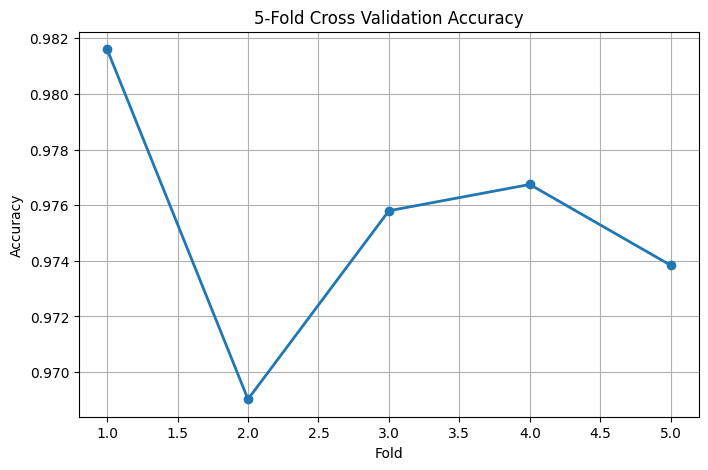

In [72]:
plt.figure(figsize=(8,5))

plt.plot(
    cv_results["Fold"],
    cv_results["Accuracy"],
    marker="o",
    linewidth=2
)

plt.title("5-Fold Cross Validation Accuracy")

plt.xlabel("Fold")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

** Model Evaluation**

Step 1: Predict Test Data

In [73]:
y_pred = best_model.predict(X_test)

Step 2: Accuracy

In [74]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy,4))

Accuracy : 0.9816


Step 3: Precision

In [75]:
precision = precision_score(
    y_test,
    y_pred,
    pos_label="spam"
)

print("Precision :", round(precision,4))

Precision : 0.9912


Step 4: Recall

In [76]:
recall = recall_score(
    y_test,
    y_pred,
    pos_label="spam"
)

print("Recall :", round(recall,4))

Recall : 0.8626


Step 5: F1 Score

In [77]:
f1 = f1_score(
    y_test,
    y_pred,
    pos_label="spam"
)

print("F1 Score :", round(f1,4))

F1 Score : 0.9224


Step 6: Classification Report

In [78]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       902
        spam       0.99      0.86      0.92       131

    accuracy                           0.98      1033
   macro avg       0.99      0.93      0.96      1033
weighted avg       0.98      0.98      0.98      1033



Step 7: Confusion Matrix

<Figure size 600x500 with 0 Axes>

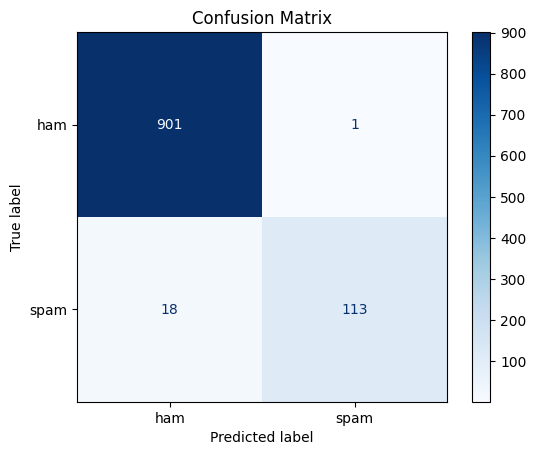

In [79]:
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.show()

Step 8: ROC Curve

In [80]:
if hasattr(best_model, "predict_proba"):

    RocCurveDisplay.from_estimator(
        best_model,
        X_test,
        y_test,
        pos_label="spam"
    )

    plt.title("ROC Curve")

    plt.show()

Step 9: Precision-Recall Curve

In [81]:
if hasattr(best_model, "predict_proba"):

    PrecisionRecallDisplay.from_estimator(
        best_model,
        X_test,
        y_test,
        pos_label="spam"
    )

    plt.title("Precision Recall Curve")

    plt.show()

Step 10: Evaluation Summary Table

In [82]:
evaluation = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Score":[
        accuracy,
        precision,
        recall,
        f1
    ]

})

evaluation

,Metric,Score
0,Accuracy,0.981607
1,Precision,0.991228
2,Recall,0.862595
3,F1 Score,0.922449


**Model Comparison Table**

Step 1: Evaluate All Models

In [83]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Naive Bayes": nb_model,
    "Logistic Regression": lr_model,
    "Linear SVM": svm_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(
        y_test,
        prediction,
        pos_label="spam"
    )

    recall = recall_score(
        y_test,
        prediction,
        pos_label="spam"
    )

    f1 = f1_score(
        y_test,
        prediction,
        pos_label="spam"
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

Step 2: Create Comparison Table

In [84]:
comparison_table = pd.DataFrame(

    results,

    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]

)

comparison_table

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.969990,0.990196,0.770992,0.866953
1,Logistic Regression,0.950629,0.987805,0.618321,0.760563
2,Linear SVM,0.981607,0.991228,0.862595,0.922449
3,Random Forest,0.977735,1.000000,0.824427,0.903766


Step 3: Sort by Accuracy

In [85]:
comparison_table = comparison_table.sort_values(
    by="Accuracy",
    ascending=False
)

comparison_table

,Model,Accuracy,Precision,Recall,F1 Score
2,Linear SVM,0.981607,0.991228,0.862595,0.922449
3,Random Forest,0.977735,1.000000,0.824427,0.903766
0,Naive Bayes,0.969990,0.990196,0.770992,0.866953
1,Logistic Regression,0.950629,0.987805,0.618321,0.760563


Step 4: Plot Model Comparison

/tmp/ipykernel_1437/691372762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


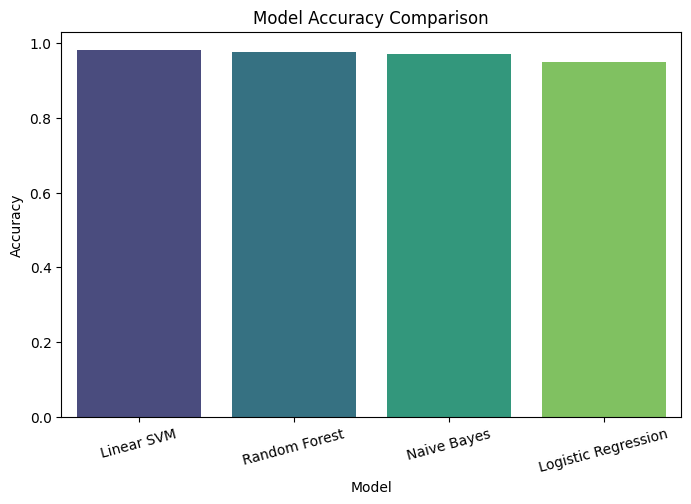

In [86]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_table,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.xticks(rotation=15)

plt.title("Model Accuracy Comparison")

plt.show()

**Select Best Model**

Step 1: Select Best Model Automatically

In [87]:
best_model_name = comparison_table.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Linear SVM


Step 2: Assign Best Model

In [88]:
if best_model_name == "Naive Bayes":

    best_model = nb_model

elif best_model_name == "Logistic Regression":

    best_model = lr_model

elif best_model_name == "Linear SVM":

    best_model = svm_model

else:

    best_model = rf_model

Step 3: Display Best Model

In [89]:
print(best_model)

LinearSVC(random_state=42)


Step 4: Display Final Accuracy

In [90]:
best_prediction = best_model.predict(X_test)

print("Final Accuracy:")

print(round(
    accuracy_score(y_test, best_prediction),
    4
))

Final Accuracy:
0.9816


Step 5: Save the Best Model

In [91]:
import joblib

joblib.dump(best_model, "spam_model.pkl")

joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model Saved Successfully")

Model Saved Successfully


Step 6: Verify Saved Files

In [92]:
import os

print(os.listdir())

['.config', 'tfidf_vectorizer.pkl', 'spam_model.pkl', 'spam.csv', 'sample_data']


**Prediction Function**

Step 1: Load Saved Files

In [93]:
model = joblib.load("spam_model.pkl")

vectorizer = joblib.load("tfidf_vectorizer.pkl")

Step 2: Prediction Function

In [94]:
def predict_message(message):

    processed = preprocess_text(message)

    vector = vectorizer.transform([processed])

    prediction = model.predict(vector)[0]

    if prediction == 1:
        return "Spam"

    return "Ham"

In [95]:
def predict_message(message):

    # Preprocess input message
    processed = preprocess_text(message)

    # Convert to TF-IDF
    vector = vectorizer.transform([processed])

    # Predict
    prediction = model.predict(vector)[0]

    if prediction == "spam":
        return " Spam"

    return " Ham"

**Test with Custom Messages**

Example 1 (Spam)

In [96]:
message = """
Congratulations!

You have won ₹50,000.

Click the link below to claim your prize immediately.

Offer expires today.
"""

print(predict_message(message))

 Spam


Example 2 (Ham)

In [97]:
message = """
Hi Rahul,

Our meeting is scheduled for tomorrow at 10:00 AM.

Please bring the project report.

Thanks.
"""

print(predict_message(message))

 Ham


Example 3 (Spam)

In [98]:
message = """
Dear Customer,

Your account has been selected for a free iPhone.

Verify your details now.

Limited time offer.
"""

print(predict_message(message))

 Ham


Interactive User Input

In [99]:
user_message = input("Enter your message: ")

print("\nPrediction:")

print(predict_message(user_message))

Enter your message: she is pretty

Prediction:
 Ham


In [100]:
user_message = input("Enter your message: ")

print("\nPrediction:")

print(predict_message(user_message))

Enter your message: click on this link

Prediction:
 Spam
